# Notebook 02 - EDA + Feature Engineering

```
S3 Silver  ──►  EDA  ──►  Feature Engineering  ──►  S3 Gold
```

In [1]:
%pip install -r ../requirements.txt -q
%pip install jsonpath-ng -q

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


## 0. Configuración

In [1]:
import logging
import yaml
import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import awswrangler as wr
from pathlib import Path
from datetime import datetime

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s"
)
log = logging.getLogger(__name__)

with open("../config.yaml") as f:
    CFG = yaml.safe_load(f)

BUCKET      = CFG["aws"]["s3_bucket"]
SILVER_PATH = f"s3://{BUCKET}/{CFG['aws']['s3_paths']['silver']}"
GOLD_PATH   = f"s3://{BUCKET}/{CFG['aws']['s3_paths']['gold']}"

log.info(f"Silver : {SILVER_PATH}")
log.info(f"Gold   : {GOLD_PATH}")

2026-05-22 02:28:06,413 [INFO] Silver : s3://itam-final-azucena/auto-repair-shop/silver


2026-05-22 02:28:06,414 [INFO] Gold   : s3://itam-final-azucena/auto-repair-shop/gold


## 1. Carga desde Silver

In [2]:
log.info("Leyendo Silver...")
df_log = wr.s3.read_parquet(path=f"{SILVER_PATH}/logistics/")
df_svc = wr.s3.read_parquet(path=f"{SILVER_PATH}/service/")

log.info(f"Logistics Silver : {df_log.shape[0]:,} filas x {df_log.shape[1]} columnas")
log.info(f"Service Silver   : {df_svc.shape[0]:,} filas x {df_svc.shape[1]} columnas")

2026-05-22 02:28:09,836 [INFO] Leyendo Silver...


2026-05-22 02:28:09,927 [INFO] Initializing a Ray instance


2026-05-22 02:28:11,491	WARNING services.py:2137 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 1909415936 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=4.34gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.


2026-05-22 02:28:11,651	INFO worker.py:2007 -- Started a local Ray instance.


/opt/conda/lib/python3.12/site-packages/ray/_private/worker.py:2046: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


2026-05-22 02:28:14,717 [INFO] Logistics Silver : 92,000 filas x 27 columnas


2026-05-22 02:28:14,718 [INFO] Service Silver   : 500 filas x 7 columnas


In [3]:
df_log.head(3)

,Vehicle_ID,Make_and_Model,Year_of_Manufacture,Vehicle_Type,Usage_Hours,Route_Info,Load_Capacity,Actual_Load,Last_Maintenance_Date,Maintenance_Type,...,Brake_Condition,Failure_History,Anomalies_Detected,Predictive_Score,Maintenance_Required,Weather_Conditions,Road_Conditions,Delivery_Times,Downtime_Maintenance,Impact_on_Efficiency
0,1,Ford F-150,2022,Truck,530,Rural,7.534549,9.004247,2023-04-09,Oil Change,...,Good,1,0,0.171873,1,Clear,Highway,30.000000,0.093585,0.150063
1,2,Volvo Fh,2015,Van,10679,Rural,7.671728,6.111785,2023-07-20,Tire Rotation,...,Fair,1,0,0.246670,1,Clear,Rural,30.000000,3.361201,0.343017
2,3,Chevy Silverado,2022,Van,4181,Rural,2.901159,3.006055,2023-03-17,Oil Change,...,Good,1,1,0.455236,1,Clear,Highway,48.627823,1.365300,0.100000


## 2. EDA - Logistics

### Balance del target

=== TARGET: Maintenance_Required ===
  0 (no requiere): 21,345  (23.2%)
  1 (requiere)   : 70,655  (76.8%)


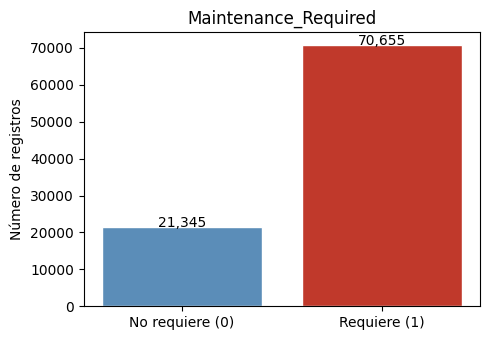

In [4]:
target_counts = df_log["Maintenance_Required"].value_counts()
target_pct    = df_log["Maintenance_Required"].value_counts(normalize=True).round(3)

print("=== TARGET: Maintenance_Required ===")
print(f"  0 (no requiere): {target_counts[0]:,}  ({target_pct[0]*100:.1f}%)")
print(f"  1 (requiere)   : {target_counts[1]:,}  ({target_pct[1]*100:.1f}%)")

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(["No requiere (0)", "Requiere (1)"],
       [target_counts[0], target_counts[1]],
       color=["#5B8DB8", "#C0392B"], edgecolor="white")
ax.set_title("Maintenance_Required", fontsize=12)
ax.set_ylabel("Número de registros")
for i, v in enumerate([target_counts[0], target_counts[1]]):
    ax.text(i, v + 200, f"{v:,}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

###  Distribución de variables numéricas clave


Features para EDA: ['Usage_Hours', 'Tire_Pressure', 'Fuel_Consumption', 'Battery_Status', 'Vibration_Levels', 'Failure_History', 'Anomalies_Detected', 'Delivery_Times']


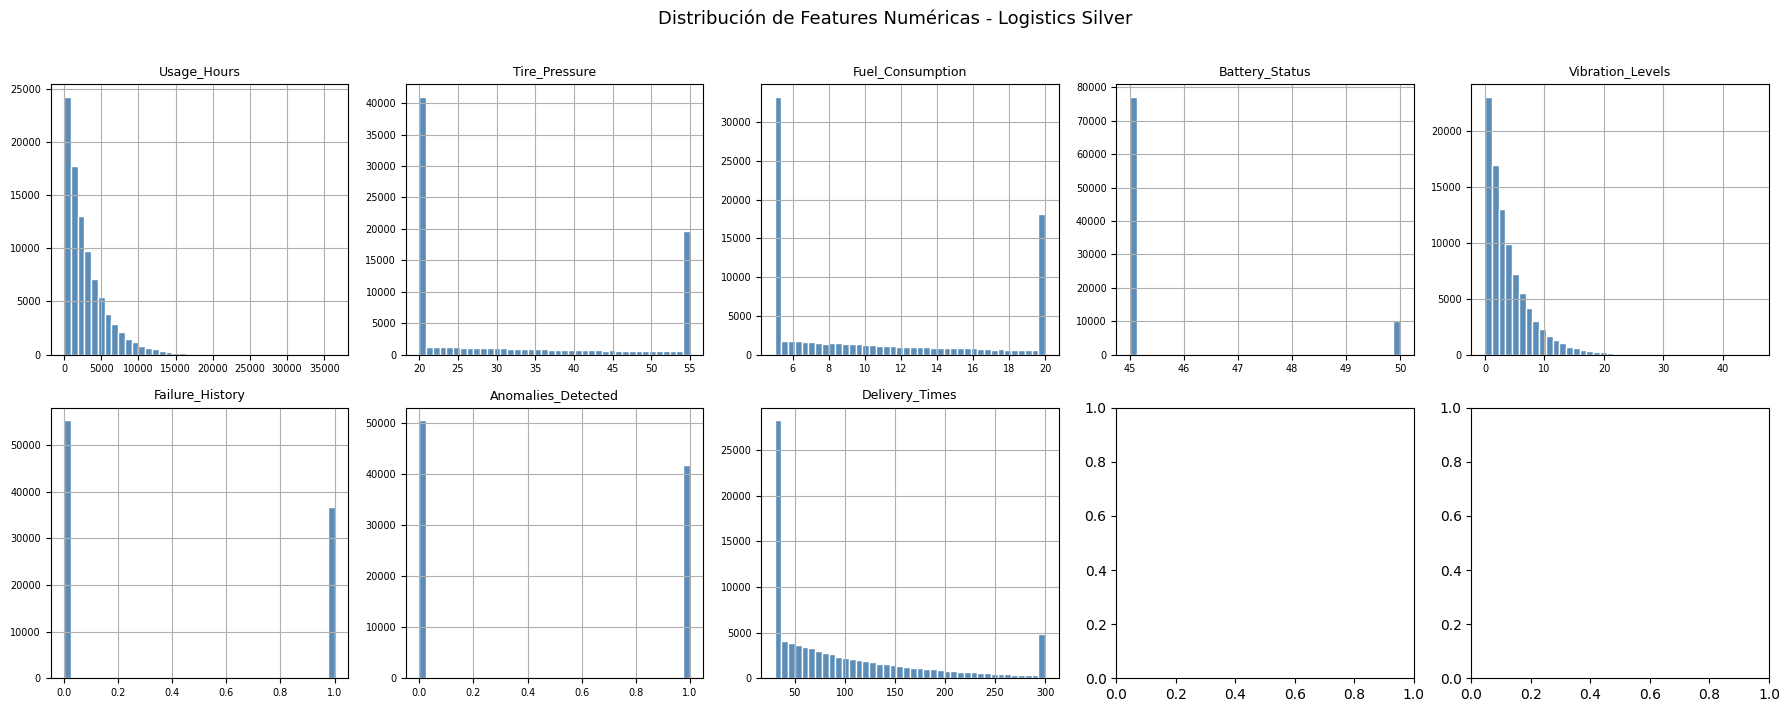

In [5]:
# Leer features desde config 

num_features = [
    f for f in CFG["modeling"]["features"]["numeric"]
    if f not in ("days_since_maintenance", "load_ratio")
]
print(f"Features para EDA: {num_features}")

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(num_features):
    df_log[col].hist(ax=axes[i], bins=40, color="#5B8DB8", edgecolor="white")
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")
    axes[i].tick_params(labelsize=7)

plt.suptitle("Distribución de Features Numéricas - Logistics Silver", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Distribución por Vehicle_Type y Route_Info

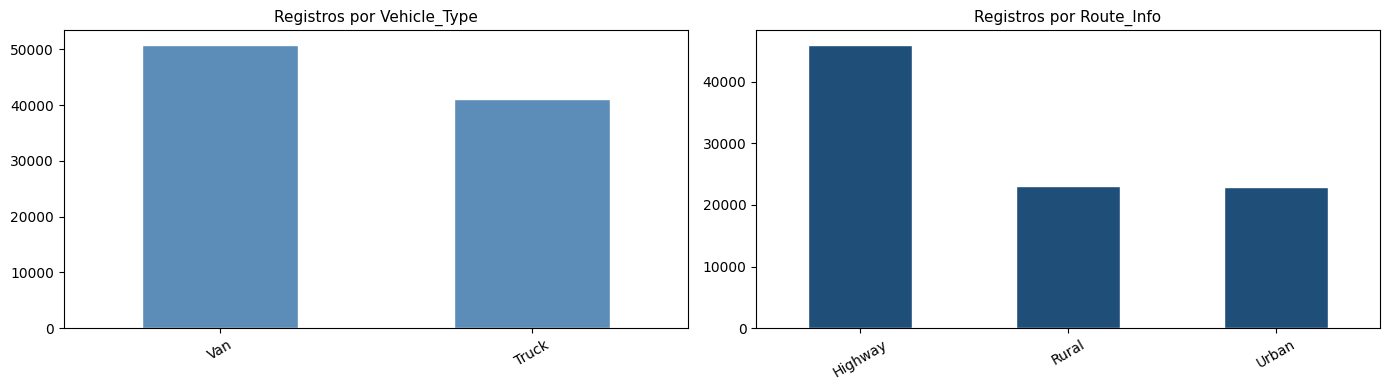

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_log["Vehicle_Type"].value_counts().plot(
    kind="bar", ax=axes[0], color="#5B8DB8", edgecolor="white"
)
axes[0].set_title("Registros por Vehicle_Type", fontsize=11)
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

df_log["Route_Info"].value_counts().plot(
    kind="bar", ax=axes[1], color="#1F4E79", edgecolor="white"
)
axes[1].set_title("Registros por Route_Info", fontsize=11)
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### Correlación de features numéricas con el target

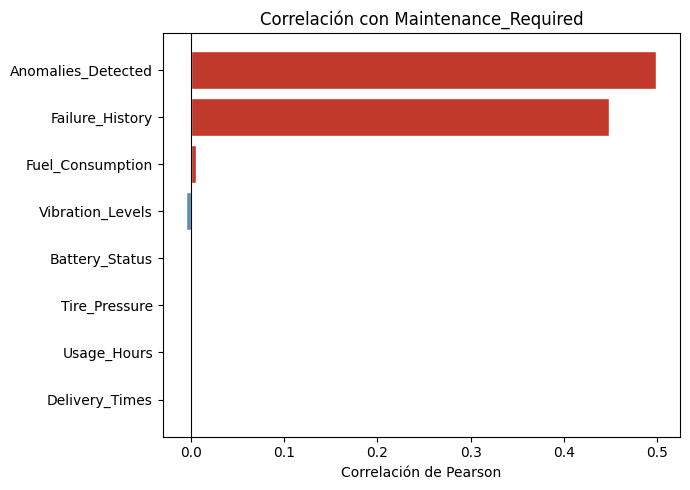


Correlaciones:
Anomalies_Detected    0.499375
Failure_History       0.448371
Fuel_Consumption      0.005376
Vibration_Levels     -0.005181
Battery_Status        0.000771
Tire_Pressure        -0.000601
Usage_Hours          -0.000459
Delivery_Times        0.000261


In [7]:
corr_target = (
    df_log[num_features + ["Maintenance_Required"]]
    .corr()["Maintenance_Required"]
    .drop("Maintenance_Required")
    .sort_values(key=abs, ascending=True)
)

fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#C0392B" if v > 0 else "#5B8DB8" for v in corr_target]
ax.barh(corr_target.index, corr_target.values, color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlación con Maintenance_Required", fontsize=12)
ax.set_xlabel("Correlación de Pearson")
plt.tight_layout()
plt.show()

print("\nCorrelaciones:")
print(corr_target.sort_values(key=abs, ascending=False).to_string())

### Nulos restantes en Logistics Silver

In [8]:
nulos = df_log.isnull().sum()
nulos_presentes = nulos[nulos > 0]

if len(nulos_presentes) == 0:
    log.info("Sin nulos en Logistics Silver")
else:
    print("Columnas con nulos:")
    print(nulos_presentes.to_string())

2026-05-22 02:28:32,969 [INFO] Sin nulos en Logistics Silver


## 3. EDA - Service

Dataset de conocimiento para el agente de Daniel.

In [9]:
print("=== SERVICE SILVER ===")
print(f"Shape: {df_svc.shape}")
df_svc.head(3)

=== SERVICE SILVER ===
Shape: (500, 7)


,customer_id,city,state,service_history,common_problem,solution_used,vehicle_company
0,1,Ananthapuram,Andhra Pradesh,Oil Change; Brake Repair,Brake noise,Brake pad replacement,Maruti Suzuki
1,2,Ananthapuram,Andhra Pradesh,Engine Repair; Tire Rotation,Engine overheating,Radiator replacement,Hyundai
2,3,Ananthapuram,Andhra Pradesh,Bodywork; Paint Job,Dents and scratches,Body repair and repaint,Tata Motors


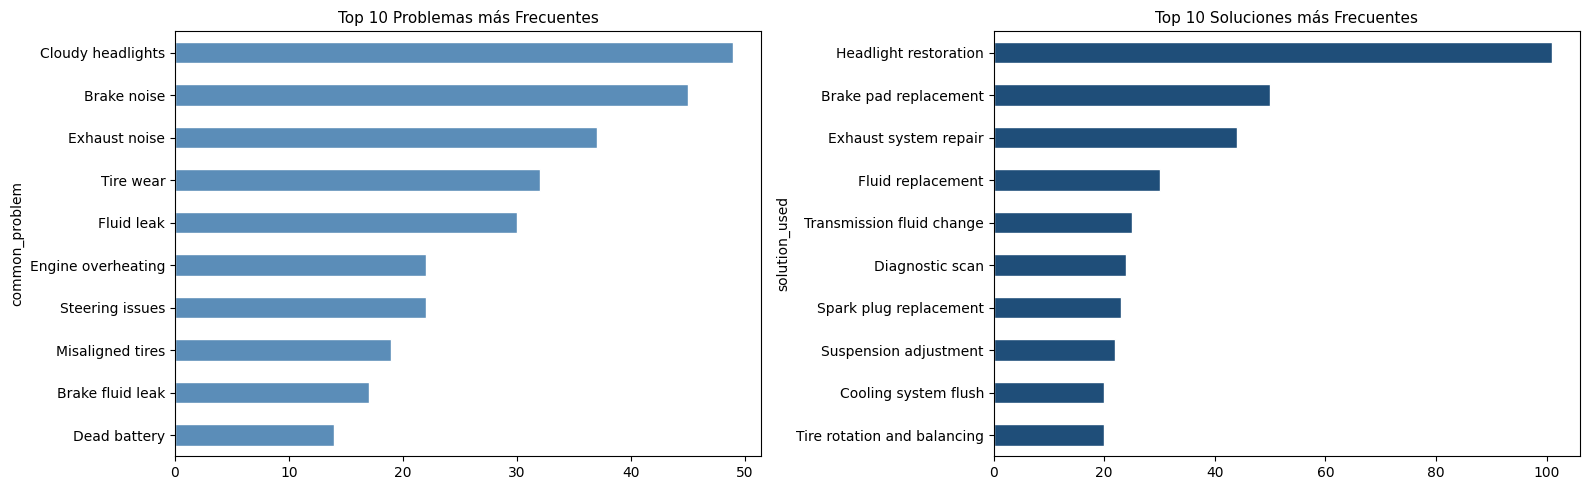

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_svc["common_problem"].value_counts().head(10).plot(
    kind="barh", ax=axes[0], color="#5B8DB8", edgecolor="white"
)
axes[0].set_title("Top 10 Problemas más Frecuentes", fontsize=11)
axes[0].invert_yaxis()

df_svc["solution_used"].value_counts().head(10).plot(
    kind="barh", ax=axes[1], color="#1F4E79", edgecolor="white"
)
axes[1].set_title("Top 10 Soluciones más Frecuentes", fontsize=11)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [11]:
print("Registros por vehicle_company:")
print(df_svc["vehicle_company"].value_counts().to_string())

Registros por vehicle_company:
vehicle_company
Hyundai                        45
Ford                           40
Volkswagen                     34
Hero MotoCorp                  33
Tata Motors                    32
Bajaj Auto                     29
Kia                            27
Toyota                         24
Nissan                         24
Audi                           22
Mahindra                       18
Renault                        17
Honda                          15
TVS Motor Company              13
Maruti Suzuki                  10
Tata Nexon                      7
Ford EcoSport                   6
Hyundai Creta                   5
Renault Duster                  4
Nissan Kicks                    4
Tata Harrier                    4
MG Hector                       3
Skoda Kushaq                    3
Hyundai Venue                   3
Mahindra & Mahindra             3
Mahindra Thar                   3
Maruti Swift                    3
Honda Accord                    3
R

## 4. Feature Engineering

| Feature | Fórmula | Justificación |
|---|---|---|
| `days_since_maintenance` | `hoy - Last_Maintenance_Date` | Vehículos sin mantenimiento reciente tienen mayor riesgo |
| `load_ratio` | `Actual_Load / Load_Capacity` | Sobrecarga acelerada el desgaste |

In [12]:
today = pd.Timestamp(datetime.today().date())

df_log["days_since_maintenance"] = (
    today - pd.to_datetime(df_log["Last_Maintenance_Date"])
).dt.days

# 0 para fechas futuras erróneas
df_log["days_since_maintenance"] = df_log["days_since_maintenance"].clip(lower=0)

# evitar división por cero
df_log["load_ratio"] = df_log["Actual_Load"] / df_log["Load_Capacity"].replace(0, np.nan)

log.info(f"days_since_maintenance — media: {df_log['days_since_maintenance'].mean():.1f} días")
log.info(f"load_ratio             — media: {df_log['load_ratio'].mean():.3f}")

2026-05-22 02:28:40,294 [INFO] days_since_maintenance — media: 963.9 días


2026-05-22 02:28:40,295 [INFO] load_ratio             — media: 0.949


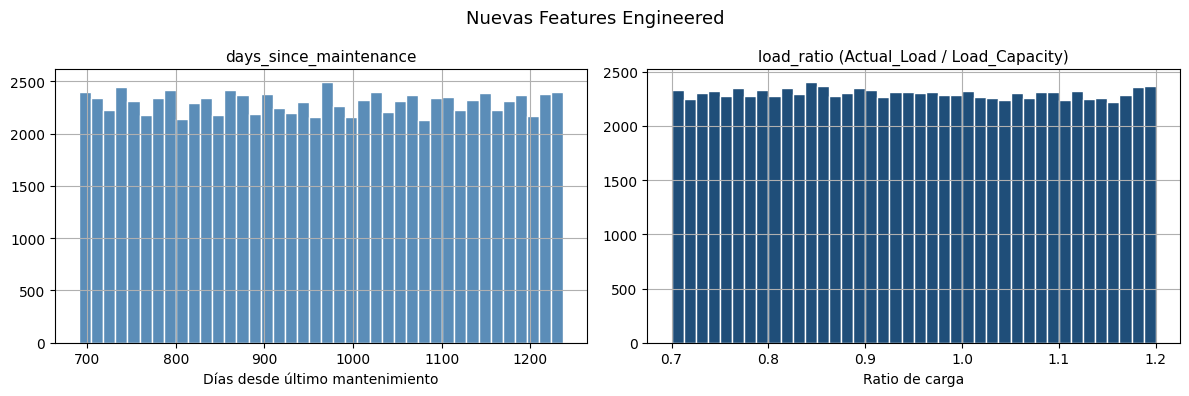

In [13]:
# Visualizar las nuevas features
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_log["days_since_maintenance"].hist(ax=axes[0], bins=40, color="#5B8DB8", edgecolor="white")
axes[0].set_title("days_since_maintenance", fontsize=11)
axes[0].set_xlabel("Días desde último mantenimiento")

df_log["load_ratio"].hist(ax=axes[1], bins=40, color="#1F4E79", edgecolor="white")
axes[1].set_title("load_ratio (Actual_Load / Load_Capacity)", fontsize=11)
axes[1].set_xlabel("Ratio de carga")

plt.suptitle("Nuevas Features Engineered", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Gold Layer

Columnas que entran al modelo + el target.

In [14]:
numeric_feats     = CFG["modeling"]["features"]["numeric"]
categorical_feats = CFG["modeling"]["features"]["categorical"]
target_col        = CFG["modeling"]["target_col"]

gold_cols = ["Vehicle_ID", "Last_Maintenance_Date"] + numeric_feats + categorical_feats + [target_col]

log.info(f"Features numéricas   : {len(numeric_feats)}")
log.info(f"Features categóricas : {len(categorical_feats)}")
log.info(f"Total columnas Gold  : {len(gold_cols)}")

df_gold = df_log[gold_cols].copy()

# Eliminar filas con nulos en nuevas variables
antes = len(df_gold)
df_gold = df_gold.dropna(subset=["days_since_maintenance", "load_ratio"])
log.info(f"Filas eliminadas por nulos en features engineered: {antes - len(df_gold)}")
log.info(f"Gold shape final: {df_gold.shape}")

2026-05-22 02:28:46,227 [INFO] Features numéricas   : 10


2026-05-22 02:28:46,228 [INFO] Features categóricas : 6


2026-05-22 02:28:46,229 [INFO] Total columnas Gold  : 19


2026-05-22 02:28:46,296 [INFO] Filas eliminadas por nulos en features engineered: 0


2026-05-22 02:28:46,297 [INFO] Gold shape final: (92000, 19)


In [15]:
df_gold.head(3)

,Vehicle_ID,Last_Maintenance_Date,Usage_Hours,Tire_Pressure,Fuel_Consumption,Battery_Status,Vibration_Levels,Failure_History,Anomalies_Detected,Delivery_Times,days_since_maintenance,load_ratio,Vehicle_Type,Route_Info,Oil_Quality,Brake_Condition,Weather_Conditions,Road_Conditions,Maintenance_Required
0,1,2023-04-09,530,20.0,5.000000,45.0,2.247033,1,0,30.000000,1139,1.195061,Truck,Rural,80.39380337354066,Good,Clear,Highway,1
1,2,2023-07-20,10679,20.0,5.000000,45.0,0.851417,1,0,30.000000,1037,0.796663,Van,Rural,91.30246087921014,Fair,Clear,Rural,1
2,3,2023-03-17,4181,55.0,13.006892,50.0,4.984557,1,1,48.627823,1162,1.036157,Van,Rural,70.10902101641098,Good,Clear,Highway,1


In [16]:
# Verificación de nulos
nulos_gold = df_gold[numeric_feats].isnull().sum()
if nulos_gold.sum() == 0:
    log.info("Gold: sin nulos en features numéricas OK")
else:
    print("Nulos en Gold:")
    print(nulos_gold[nulos_gold > 0].to_string())

2026-05-22 02:28:52,308 [INFO] Gold: sin nulos en features numéricas OK


## 6. Guardar en S3 Gold

In [17]:
log.info("Guardando Gold en S3...")
wr.s3.to_parquet(
    df=df_gold,
    path=f"{GOLD_PATH}/features/",
    dataset=True,
    mode="overwrite"
)
log.info("Gold guardado OK")

2026-05-22 02:28:54,680 [INFO] Guardando Gold en S3...


2026-05-22 02:28:56,963 [INFO] Gold guardado OK


## 7. Verificación final

In [18]:
df_gold_check = wr.s3.read_parquet(path=f"{GOLD_PATH}/features/")
log.info(f"Gold leído desde S3: {df_gold_check.shape}")

assert df_gold_check.shape[0] == df_gold.shape[0], "Discrepancia en filas Gold"
assert df_gold_check.shape[1] == df_gold.shape[1], "Discrepancia en columnas Gold"

log.info("Verificación OK")
print("Resumen Gold:")
print(f"  Filas   : {df_gold_check.shape[0]:,}")
print(f"  Columnas: {df_gold_check.shape[1]}")
print(f"  Target  : {df_gold_check[target_col].value_counts().to_dict()}")

2026-05-22 02:28:59,696 [INFO] Gold leído desde S3: (92000, 19)


2026-05-22 02:28:59,697 [INFO] Verificación OK


Resumen Gold:
  Filas   : 92,000
  Columnas: 19
  Target  : {1: 70655, 0: 21345}
